<a href="https://colab.research.google.com/github/hetalsharmaaa/perzonix/blob/main/shoppersintent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

%matplotlib inline
sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
df.info()
df.describe(include="all")
df["Revenue"].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,proportion
Revenue,
False,0.845255
True,0.154745


In [3]:
df.isnull().sum()
df.isnull().sum().sum()

np.int64(0)

In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 125
Shape after dropping duplicates: (12205, 18)


In [5]:
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [6]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational",
                 "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                 "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

df[numeric_cols].describe()

print((df["Administrative_Duration"] < 0).sum())
print((df["BounceRates"] > 1).sum())
print((df["ExitRates"] > 1).sum())

0
0
0


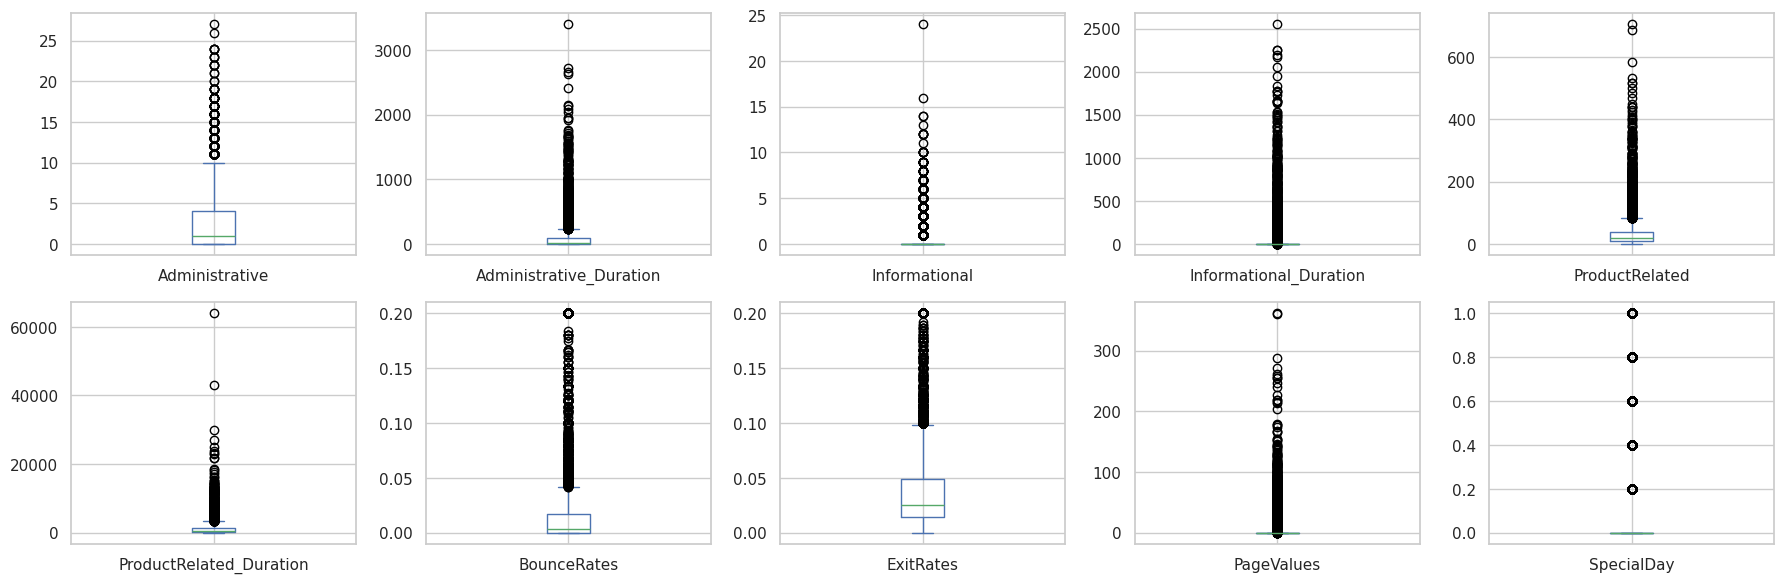

In [7]:
import matplotlib.pyplot as plt
df[numeric_cols].plot(kind="box", subplots=True, layout=(2,5), figsize=(18,6))
plt.tight_layout()
plt.show()

In [8]:
for col in ["Month", "VisitorType", "Weekend", "Revenue"]:
    print(col, ":", df[col].unique())

Month : ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
VisitorType : ['Returning_Visitor' 'New_Visitor' 'Other']
Weekend : [False  True]
Revenue : [False  True]


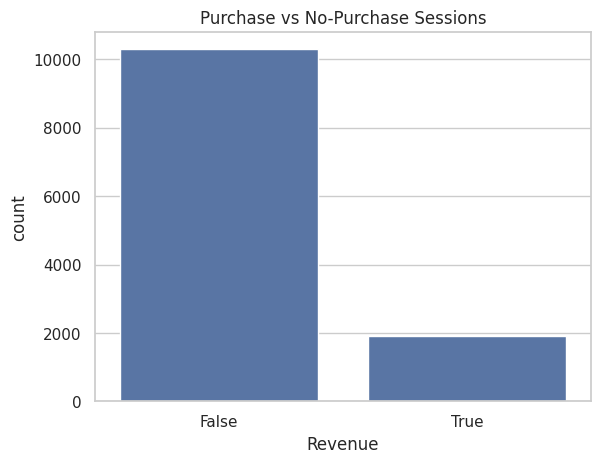

Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64


In [9]:
sns.countplot(x="Revenue", data=df)
plt.title("Purchase vs No-Purchase Sessions")
plt.show()

print(df["Revenue"].value_counts(normalize=True) * 100)

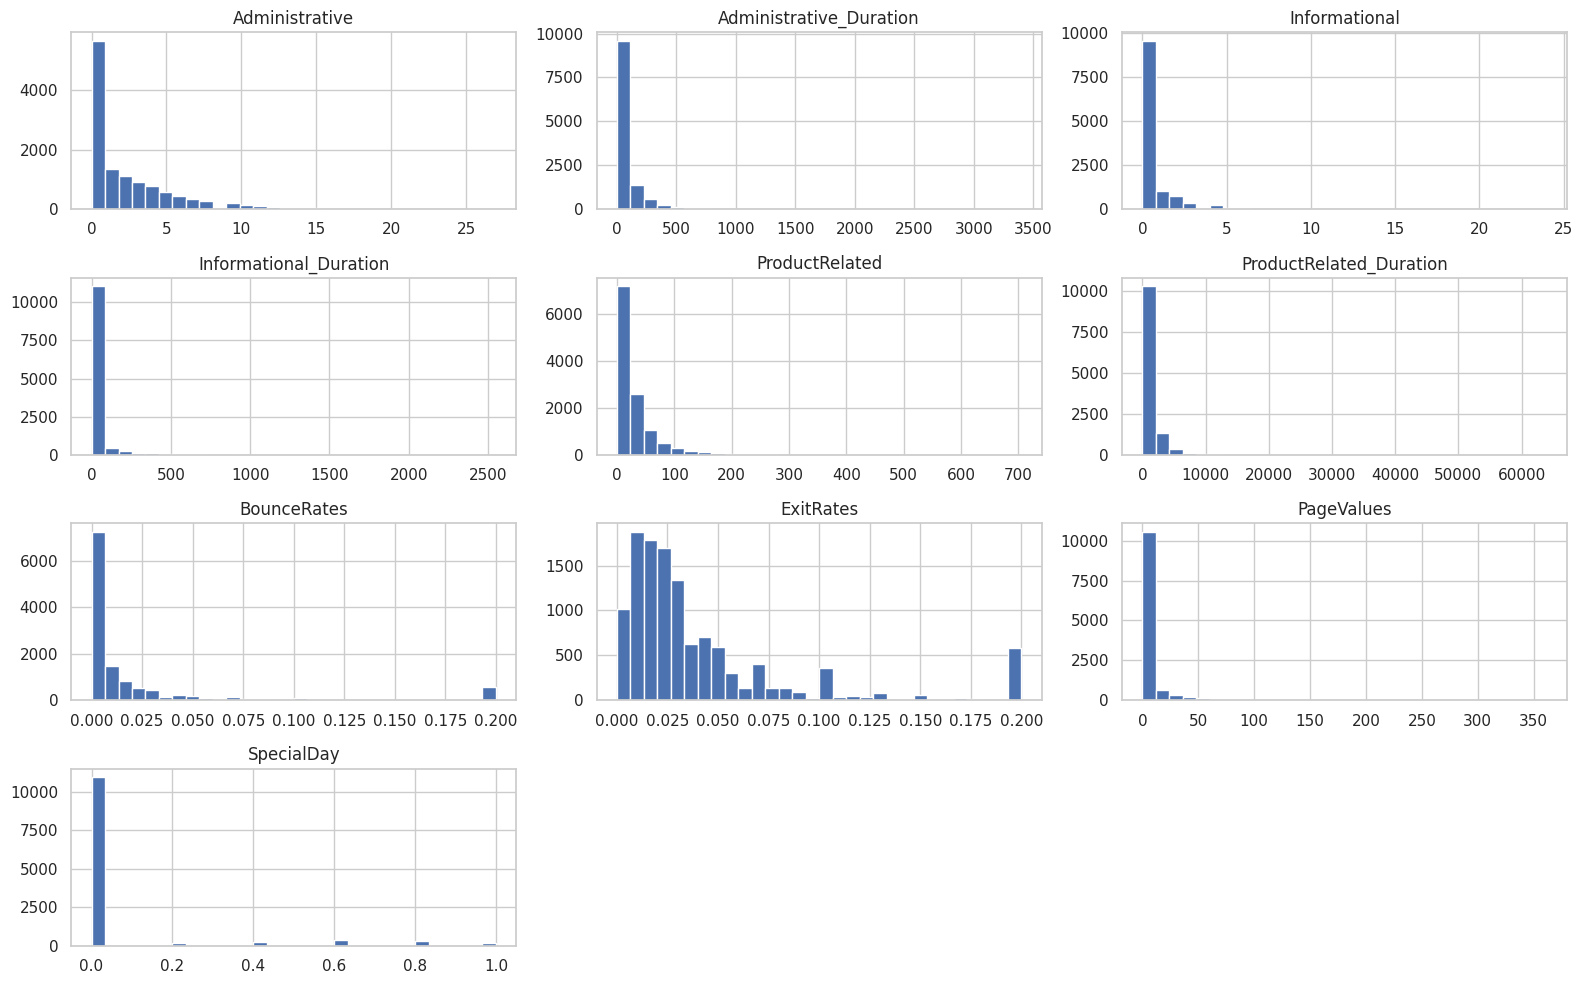

In [10]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational",
                 "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                 "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

df[numeric_cols].hist(bins=30, figsize=(16,10))
plt.tight_layout()
plt.show()

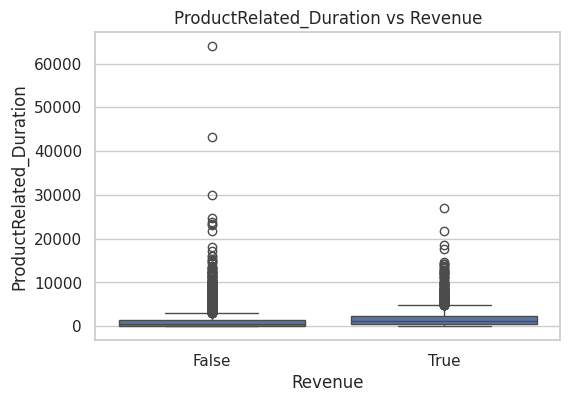

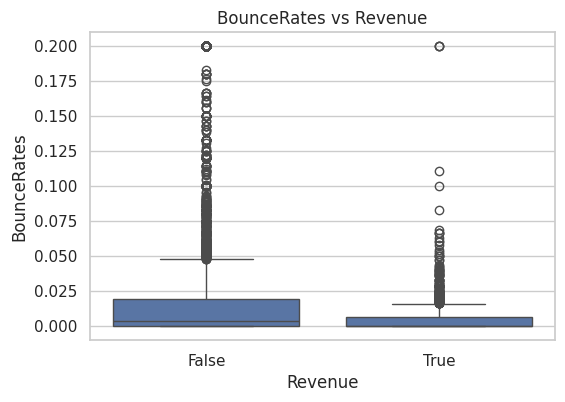

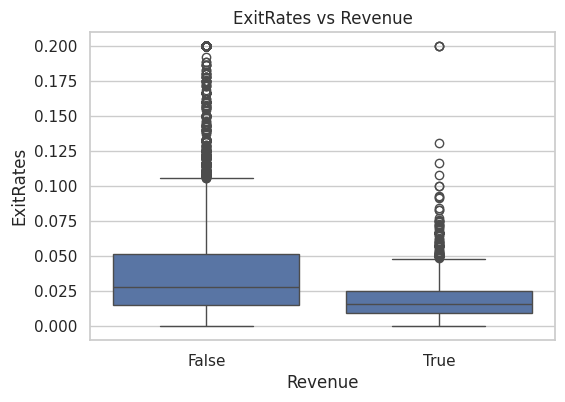

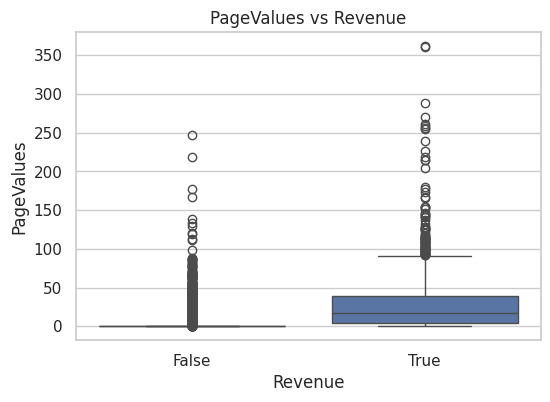

In [11]:
for col in ["ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Revenue", y=col, data=df)
    plt.title(f"{col} vs Revenue")
    plt.show()

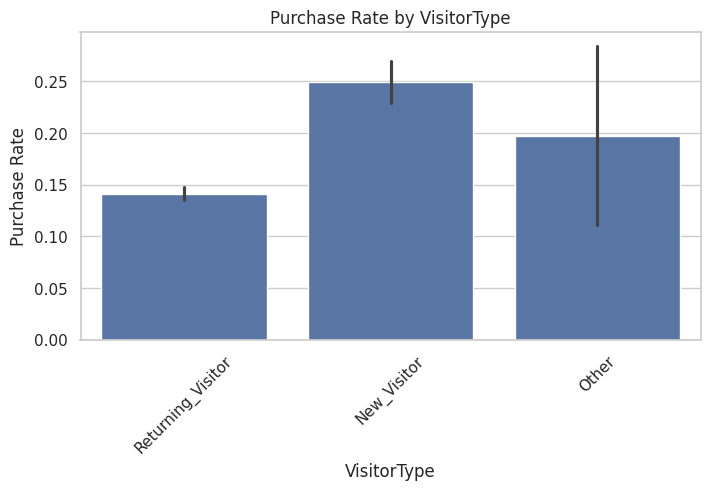

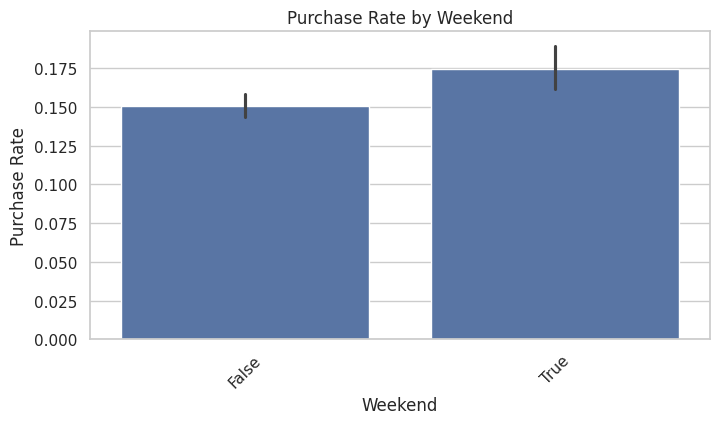

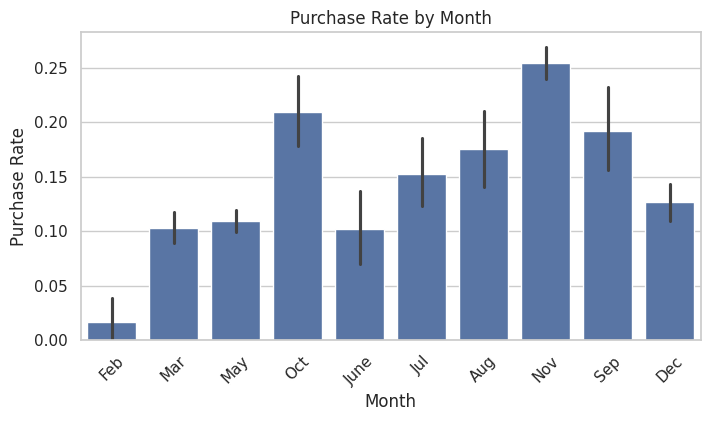

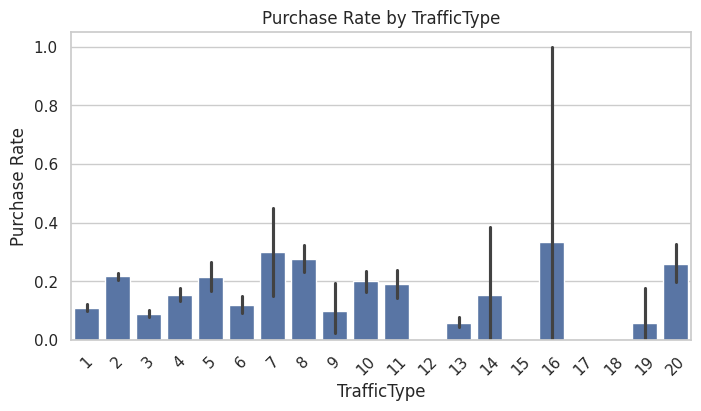

In [12]:
for col in ["VisitorType", "Weekend", "Month", "TrafficType"]:
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y=df["Revenue"].astype(int), data=df, estimator=lambda x: sum(x)/len(x))
    plt.title(f"Purchase Rate by {col}")
    plt.ylabel("Purchase Rate")
    plt.xticks(rotation=45)
    plt.show()

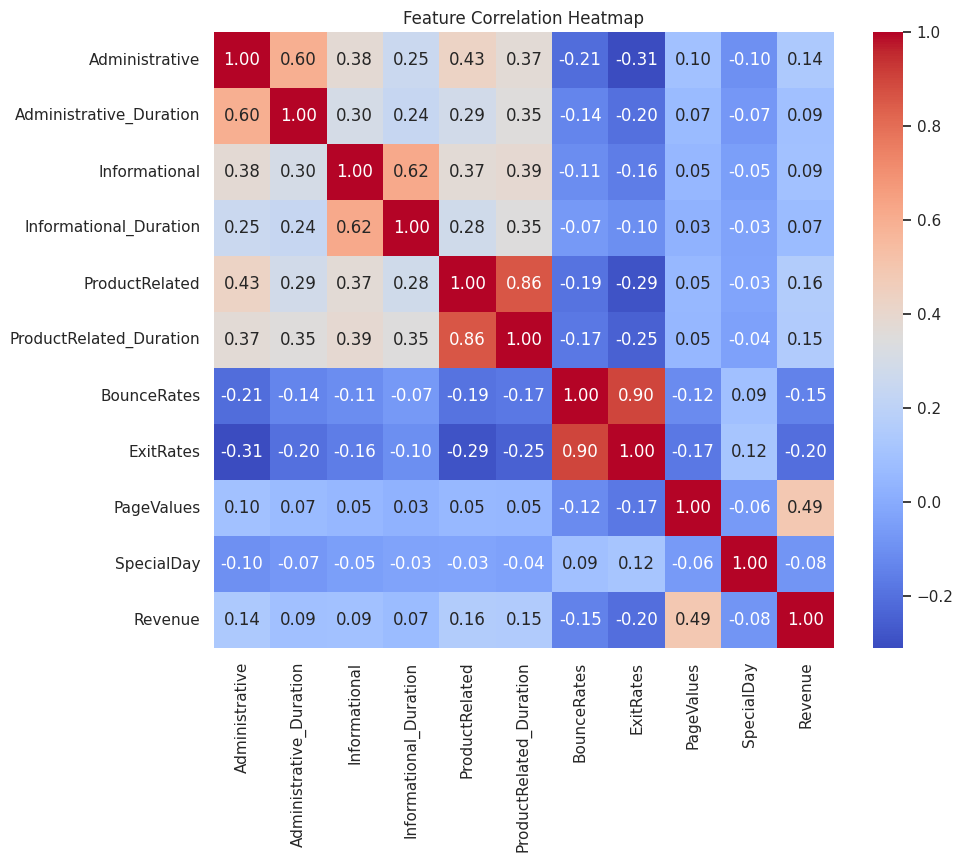

In [13]:
plt.figure(figsize=(10,8))
corr = df[numeric_cols + ["Revenue"]].copy()
corr["Revenue"] = corr["Revenue"].astype(int)
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [14]:
df["TotalPages"] = df["Administrative"] + df["Informational"] + df["ProductRelated"]
df["TotalDuration"] = df["Administrative_Duration"] + df["Informational_Duration"] + df["ProductRelated_Duration"]


df["AvgProductDuration"] = df["ProductRelated_Duration"] / df["ProductRelated"].replace(0, np.nan)
df["AvgProductDuration"] = df["AvgProductDuration"].fillna(0)


df["ProductPageRatio"] = df["ProductRelated"] / df["TotalPages"].replace(0, np.nan)
df["ProductPageRatio"] = df["ProductPageRatio"].fillna(0)

df["IsBounceSession"] = (df["BounceRates"] > 0).astype(int)

In [15]:
skewed_cols = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration", "TotalDuration"]

for col in skewed_cols:
    df[col + "_log"] = np.log1p(df[col])

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Weekend"] = le.fit_transform(df["Weekend"])
df["Revenue"] = le.fit_transform(df["Revenue"])
df["VisitorType"] = le.fit_transform(df["VisitorType"])

In [17]:
df = pd.get_dummies(df, columns=["Month", "OperatingSystems", "Browser", "Region", "TrafficType"], drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Revenue"])
y = df["Revenue"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
numeric_features = X_train.select_dtypes(include=["float64", "int64"]).columns

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(9764, 76) (2441, 76)
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64


In [19]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=8)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for name, preds in models.items():
    print(f"{name}: {accuracy_score(y_test, preds):.4f}")

Logistic Regression: 0.8861
Decision Tree: 0.8923
Random Forest: 0.8988
Gradient Boosting: 0.8988


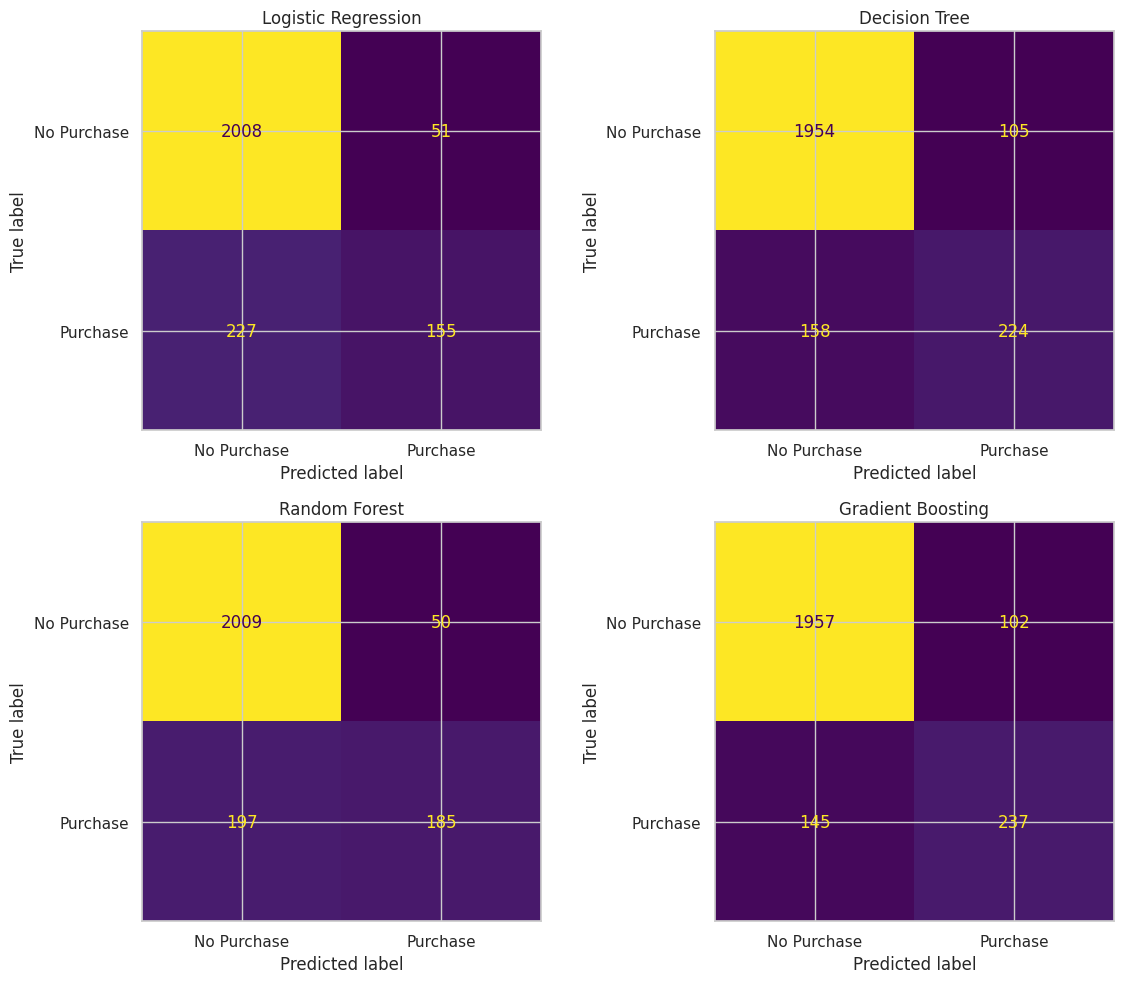

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_preds = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for ax, (name, preds) in zip(axes.flat, models_preds.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import classification_report

for name, preds in models_preds.items():
    print(f"\n{name}")
    print(classification_report(y_test, preds, target_names=["No Purchase", "Purchase"]))


Logistic Regression
              precision    recall  f1-score   support

 No Purchase       0.90      0.98      0.94      2059
    Purchase       0.75      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.73      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
              precision    recall  f1-score   support

 No Purchase       0.93      0.95      0.94      2059
    Purchase       0.68      0.59      0.63       382

    accuracy                           0.89      2441
   macro avg       0.80      0.77      0.78      2441
weighted avg       0.89      0.89      0.89      2441


Random Forest
              precision    recall  f1-score   support

 No Purchase       0.91      0.98      0.94      2059
    Purchase       0.79      0.48      0.60       382

    accuracy                           0.90      2441
   macro avg       0.85      0.73      0.77      2441
weighted avg       0.89

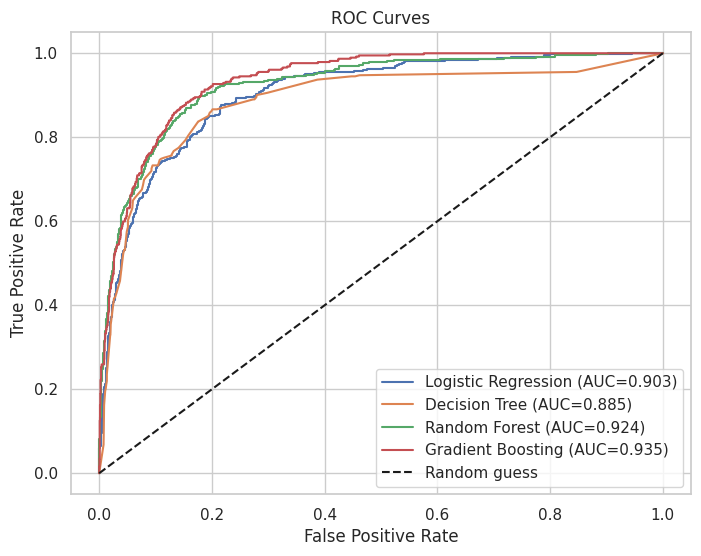

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve

probs = {
    "Logistic Regression": log_reg.predict_proba(X_test_scaled)[:, 1],
    "Decision Tree": dt.predict_proba(X_test)[:, 1],
    "Random Forest": rf.predict_proba(X_test)[:, 1],
    "Gradient Boosting": gb.predict_proba(X_test)[:, 1]
}

plt.figure(figsize=(8, 6))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}


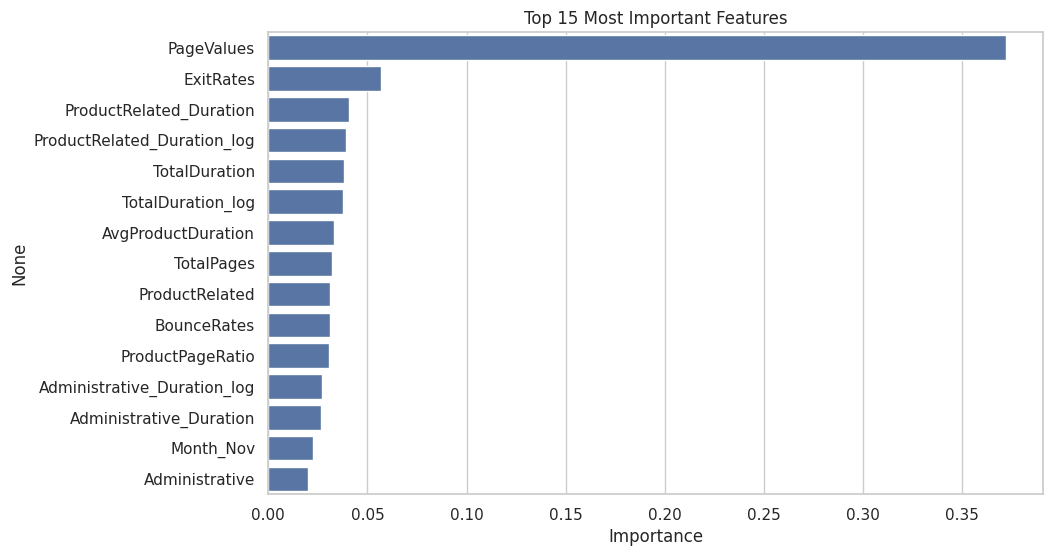

In [29]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.show()